# Research Paper Recommendation System

## Objective
The goal of this project is to build an intelligent research paper recommendation system using:

- TF-IDF Vectorization
- Cosine Similarity
- BERT Embeddings
- FAISS Similarity Search
- Random Forest Classification
- XGBoost Classification

This system recommends similar research papers based on semantic and keyword similarity while also performing topic classification.

## Dataset Sampling

A smaller subset of the dataset is used in this repository to keep the project lightweight and PR-friendly.

This improves:
- Faster execution
- Easier reproducibility
- Reduced repository size
- Faster notebook testing

In [5]:
import pandas as pd

# Load original dataset
large_df = pd.read_csv("../data/arXiv_dataset.csv")

# Keep only first 1000 rows
df = large_df.head(5000)

# Save smaller dataset
df.to_csv("../data/sample_arxiv_dataset.csv", index=False)

print("Smaller dataset created successfully!")

Smaller dataset created successfully!


In [6]:
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (5000, 10)


# Dataset Overview

In this section, we explore the dataset structure,
features, missing values, and statistical information.
This helps us understand the quality of the dataset
before preprocessing and model building.
Understanding:
- Number of rows and columns
- Data types
- Missing values

In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (5000, 10)


In [8]:
df.columns

Index(['id', 'title', 'category', 'category_code', 'published_date',
       'updated_date', 'authors', 'first_author', 'summary',
       'summary_word_count'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  5000 non-null   str  
 1   title               5000 non-null   str  
 2   category            5000 non-null   str  
 3   category_code       5000 non-null   str  
 4   published_date      5000 non-null   str  
 5   updated_date        5000 non-null   str  
 6   authors             5000 non-null   str  
 7   first_author        5000 non-null   str  
 8   summary             5000 non-null   str  
 9   summary_word_count  5000 non-null   int64
dtypes: int64(1), str(9)
memory usage: 5.9 MB


In [10]:
df.describe()

,summary_word_count
count,5000.000000
mean,143.364200
std,58.119583
min,5.000000
25%,102.000000
50%,140.000000
75%,179.000000
max,552.000000


# Missing Value Analysis

Checking for null values before preprocessing.

In [11]:
df.isnull().sum()

id                    0
title                 0
category              0
category_code         0
published_date        0
updated_date          0
authors               0
first_author          0
summary               0
summary_word_count    0
dtype: int64

In [12]:
# Fill missing values
df['title'] = df['title'].fillna('')
df['summary'] = df['summary'].fillna('')

# Verify again
df[['title', 'summary']].isnull().sum()

title      0
summary    0
dtype: int64

# Duplicate Removal

Duplicate research papers can negatively impact recommendation quality.

In [13]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (5000, 10)


In [14]:
#Visualizing data

# Text Cleaning Function

This function cleans and preprocesses research paper text for NLP tasks.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

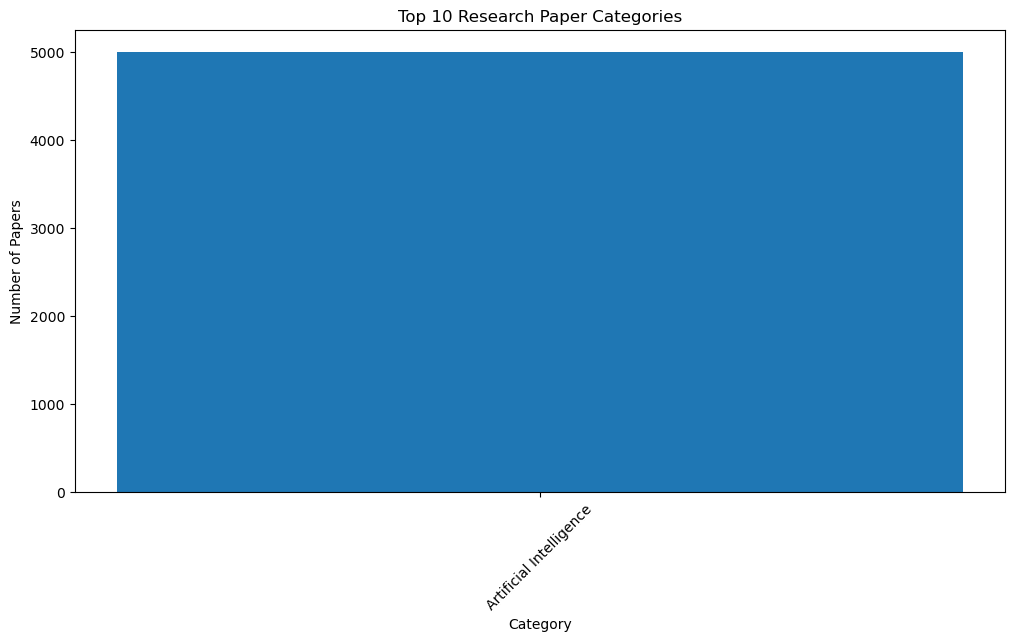

In [16]:
import matplotlib.pyplot as plt

# Category counts
category_counts = df['category'].value_counts().head(10)

# Plot
plt.figure(figsize=(12,6))

plt.bar(category_counts.index, category_counts.values)

plt.xticks(rotation=45)

plt.title("Top 10 Research Paper Categories")

plt.xlabel("Category")

plt.ylabel("Number of Papers")

plt.show()

# EDA Summary

- Dataset contains both numerical and categorical features.
- Missing values were identified in multiple columns.
- Some outliers are present.
- Feature distributions vary significantly.
- Correlation analysis shows relationships between variables.
- Further preprocessing is required before model training.

# Text Preprocessing

The preprocessing pipeline includes:

- Lowercasing
- URL removal
- HTML tag removal
- Punctuation removal
- Stopword removal
- Lemmatization

This improves text quality for NLP models.

In [17]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [18]:
#Download Required NLTK Data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\Parmpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Parmpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Parmpreet
[nltk_data]     Kaur\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [19]:
#Initialise toolsDownload Required NLTK Data
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

# Text Cleaning Function

This function cleans and preprocesses research paper text for NLP tasks.

In [20]:
# Initialize tools
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):
    
    # Convert to string
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(words)

# Combining Text Columns

Combining:
- Title
- Summary

This helps improve recommendation quality.

In [21]:
# Combine title and summary
df['combined_text'] = df['title'] + " " + df['summary']

# Apply cleaning
df['clean_text'] = df['combined_text'].apply(clean_text)

# Preview cleaned text
df[['title', 'clean_text']].head()

,title,clean_text
0,Dynamic Backtracking,dynamic backtracking occasional need return sh...
1,A Market-Oriented Programming Environment and ...,marketoriented programming environment applica...
2,An Empirical Analysis of Search in GSAT,empirical analysis search gsat describe extens...
3,The Difficulties of Learning Logic Programs wi...,difficulty learning logic program cut real log...
4,Software Agents: Completing Patterns and Const...,software agent completing pattern constructing...


# Text Length Analysis

Analyzing:
- Character count
- Word count

This helps understand dataset distribution.

In [22]:
# Character count
df['char_count'] = df['clean_text'].apply(len)

# Word count
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

df[['char_count', 'word_count']].describe()

,char_count,word_count
count,5000.000000,5000.000000
mean,768.642600,90.550200
std,291.991222,34.738256
min,69.000000,8.000000
25%,562.750000,66.000000
50%,749.000000,88.000000
75%,948.000000,112.000000
max,2661.000000,303.000000


# Word Count Distribution

Visualizing text length distribution across research papers.

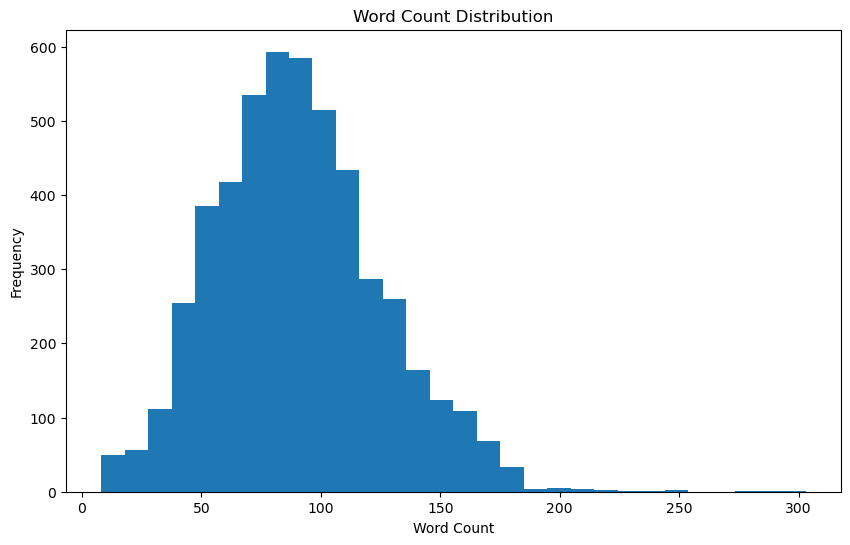

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df['word_count'], bins=30)

plt.title("Word Count Distribution")

plt.xlabel("Word Count")

plt.ylabel("Frequency")

plt.show()

# Most Common Words

Finding frequently occurring words in research paper summaries.

In [24]:
from collections import Counter

# Combine all words
all_words = " ".join(df['clean_text']).split()

# Get common words
common_words = Counter(all_words).most_common(20)

# Convert to dataframe
common_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

common_df

,Word,Frequency
0,model,4394
1,problem,4257
2,algorithm,3753
3,system,3357
4,paper,3065
5,approach,2951
6,learning,2828
7,method,2641
8,network,2408
9,set,2197


In [28]:
# Keep only 5000 rows for lightweight processing

df = df.sample(5000, random_state=42)

# Reset index
df = df.reset_index(drop=True)

print("Reduced Dataset Shape:", df.shape)

Reduced Dataset Shape: (5000, 14)


In [29]:
# Save cleaned dataset

df.to_csv("../data/cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [30]:
df.shape

(5000, 14)